### In the following notebook CPT data (GEF form) will be processed to classify in Robertson 1990 classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from pathlib import Path
from matplotlib.patches import Ellipse
from PIL import Image
from lengkeek_chart import create_lengkeek_background_axis

# The qc and fs plots comparison have been removed. The focus solemnly lays in the Robertson graph to see the ellipses and analyse the differences

### After Robertson Classification

In [4]:
# =============================================================================
# Load classified CPT data
# =============================================================================

m1 = pd.read_csv(r"C:\AA_Thesis\VSCode\ZZ_Zwolle_Wezep\Wezep\B9_S3vsS3A_S11\2300654_S3\classified_points.csv")
m2 = pd.read_csv(r"C:\AA_Thesis\VSCode\ZZ_Zwolle_Wezep\Wezep\B9_S3vsS3A_S11\2300654_S3A\classified_points.csv")
m3 = pd.read_csv(r"C:\AA_Thesis\VSCode\ZZ_Zwolle_Wezep\Wezep\B9_S3vsS3A_S11\2300654_S11\classified_points.csv")

# =============================================================================
# Select pile-carrying sand layers per CPT
# =============================================================================
# b is for before a is for after
# example input:
# "CPT1-2": {
#     "df": m1,
#     "layers": ["Sand 1"],
# },
selected_cpts = {
    "CPT-S3b": {
        "df": m1,
        # "layers": ["Sand 2", "Sand 3", "Sand 4"],
        "layers": ["Sand 1"],
    },
    "CPT-S3Aa": {
        "df": m2,
        "layers": ["Sand 1"], # sand 4 for bottom layer 
    },
    "CPT-S11a": {
        "df": m3,
        # "layers": ["Sand 2", "Sand 3", "Sand 4", "Sand 5"],
        "layers": ["Sand 1"],
    },
}

# =============================================================================
# Helper functions
# =============================================================================

def selected_layer_series(df, layers, value_col):
    """
    Return the selected value column for the selected layer IDs.
    All selected layers are combined into one series.
    """
    return (
        df.loc[df["layer_id"].isin(layers), value_col]
        .dropna()
        .astype(float)
    )


def make_describe_table(selected_cpts, value_col):
    """
    Create a describe() table with CPTs as columns.
    """
    describe_data = {}

    for cpt_name, info in selected_cpts.items():
        series = selected_layer_series(
            df=info["df"],
            layers=info["layers"],
            value_col=value_col,
        )

        describe_data[cpt_name] = series.describe()

    table = pd.DataFrame(describe_data)

    # Optional: cleaner row order
    row_order = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    table = table.loc[row_order]

    return table


# =============================================================================
# Create tables
# =============================================================================

qt_over_pa_table = make_describe_table(selected_cpts, "qt_over_pa")
rf_percent_table = make_describe_table(selected_cpts, "rf_percent")

# Display in notebook
display(qt_over_pa_table)
display(rf_percent_table)

,CPT-S3b,CPT-S3Aa,CPT-S11a
count,386.000000,220.000000,47.000000
mean,116.447772,115.976045,75.620213
std,31.694278,35.579903,5.403028
min,44.560000,62.980000,65.680000
25%,95.155000,93.827500,70.780000
50%,111.580000,109.415000,75.420000
75%,136.870000,125.635000,80.250000
max,196.410000,212.480000,84.590000


,CPT-S3b,CPT-S3Aa,CPT-S11a
count,386.000000,220.000000,47.000000
mean,0.719922,0.978318,1.039787
std,0.110603,0.203504,0.080312
min,0.380000,0.610000,0.790000
25%,0.670000,0.827500,1.025000
50%,0.720000,0.920000,1.050000
75%,0.790000,1.100000,1.070000
max,1.030000,1.460000,1.200000


CPT-S3bcentre Rf: 0.71%, centre qt/pa: 112.27
CPT-S3Aacentre Rf: 0.96%, centre qt/pa: 111.22
CPT-S11acentre Rf: 1.04%, centre qt/pa: 75.43


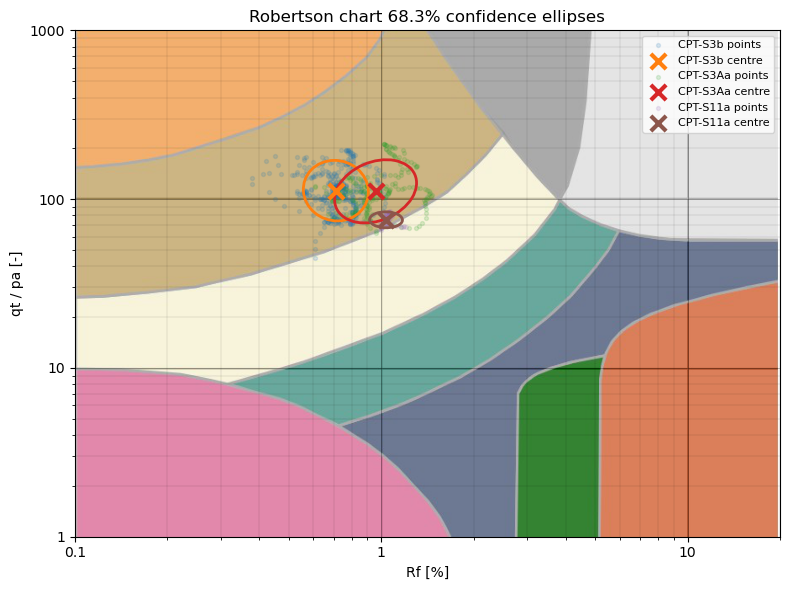

,CPT,n,centre_Rf_percent,centre_qt_over_pa,std_log10_Rf,std_log10_qt_over_pa
0,CPT-S3b,386,0.711039,112.269577,0.069829,0.117989
1,CPT-S3Aa,220,0.958263,111.224376,0.087969,0.123219
2,CPT-S11a,47,1.036557,75.431463,0.035234,0.031043


In [5]:
def selected_sand_data(df, layers):
    data = df.loc[
        df["layer_id"].isin(layers),
        ["rf_percent", "qt_over_pa"]
    ].dropna().copy()

    data = data[
        (data["rf_percent"] > 0) &
        (data["qt_over_pa"] > 0)
    ].copy()

    data["log_rf_percent"] = np.log10(data["rf_percent"])
    data["log_qt_over_pa"] = np.log10(data["qt_over_pa"])

    return data


def add_covariance_ellipse(ax, x, y, n_std=1.0, **kwargs):
    if len(x) < 3:
        return

    cov = np.cov(x, y)

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    )

    width, height = 2 * n_std * np.sqrt(eigenvalues) # times 2 for full width and height of the ellipse

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        linewidth=2,
        **kwargs
    )

    ax.add_patch(ellipse)

confidence = 1.52 # Set your confidence ellipse 1.52=68.3%, 2.45=95.4%, 2.14=90% , 1.0=1 std (39.35%), it is the square root of the chi-squared value for 2 degrees of freedom (Rf and qt/pa) at the desired confidence level

selected_cpts = {
    "CPT-S3b": {
        "df": m1,
        # "layers": ["Sand 2", "Sand 3", "Sand 4"],
        "layers": ["Sand 1"],
    },
    "CPT-S3Aa": {
        "df": m2,
        "layers": ["Sand 1"], # sand 4 for bottom layer 
    },
    "CPT-S11a": {
        "df": m3,
        # "layers": ["Sand 2", "Sand 3", "Sand 4", "Sand 5"],
        "layers": ["Sand 1"],
    },
}


background_path = r"C:\AA_Thesis\VSCode\lengkeek_vs_code\lengkeek_chart_clean.jpg"

fig, ax = create_lengkeek_background_axis(
    background_path=background_path,
    figsize=(8, 6),
    alpha=1.0
)

stats_rows = []

for name, info in selected_cpts.items():
    data = selected_sand_data(info["df"], info["layers"])

    if data.empty:
        print(f"Warning: no data for {name}")
        continue

    x = data["log_rf_percent"].values
    y = data["log_qt_over_pa"].values

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.15,
        label=f"{name} points",
        zorder=2
    )

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    centre = ax.scatter(
        x_mean,
        y_mean,
        s=120,
        marker="x",
        linewidths=3,
        label=f"{name} centre",
        zorder=4
    )

    centre_colour = centre.get_edgecolors()[0]

    add_covariance_ellipse(
        ax,
        x,
        y,
        n_std=confidence,
        edgecolor=centre_colour,
        zorder=3
    )

    stats_rows.append({
        "CPT": name,
        "n": len(data),
        "centre_Rf_percent": 10 ** x_mean,
        "centre_qt_over_pa": 10 ** y_mean,
        "std_log10_Rf": np.std(x, ddof=1),
        "std_log10_qt_over_pa": np.std(y, ddof=1),
    })

    print(
        f"{name}"
        f"centre Rf: {10**x_mean:.2f}%, "
        f"centre qt/pa: {10**y_mean:.2f}"
    )


ax.set_title("Robertson chart 68.3% confidence ellipses")
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_rows)
display(stats_df)

## Soil parameters following Table 2b in NEN-EN

In [12]:
param1_2 = pd.read_csv(r'C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU1-2\layer_parameters.csv')

param1_2.head(39)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\AA_Thesis\\VSCode\\lengkeek_vs_code\\S1022749_CPTU1-2\\layer_parameters.csv'

### dataframe made smaller up to a depth of -25 NAP so in the case of CPT1-2 Sand layer 3

In [ ]:
df = param1_2.iloc[:28].copy()

same_value_cols = [
    "gamma_unsat_kn_m3",
    "gamma_sat_kn_m3",
    "E100_mpa",
    "c_prime_kpa",
    "phi_prime_deg",
    "dilatancy_deg",
]

same_value_cols = [col for col in same_value_cols if col in df.columns]

group_id = (df[same_value_cols] != df[same_value_cols].shift()).any(axis=1).cumsum()

combined = (
    df.groupby(group_id, as_index=False)
    .agg(
        soil_id=("soil_id", lambda x: " + ".join(x.astype(str))),
        top_elevation_m_nap=("top_elevation_m_nap", "first"),
        qc_mpa_mean=("qc_mpa_mean", "mean"),
        gamma_unsat_kn_m3=("gamma_unsat_kn_m3", "first"),
        gamma_sat_kn_m3=("gamma_sat_kn_m3", "first"),
        E100_mpa=("E100_mpa", "first"),
        c_prime_kpa=("c_prime_kpa", "first"),
        phi_prime_deg=("phi_prime_deg", "first"),
        dilatancy_deg=("dilatancy_deg", "first"),
        interpolation_status=("interpolation_status", "first"),
    )
)

combined

C:\Users\caupi\AppData\Local\Temp\ipykernel_20340\2855455988.py:17: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  df.groupby(group_id, as_index=False)


,soil_id,top_elevation_m_nap,qc_mpa_mean,gamma_unsat_kn_m3,gamma_sat_kn_m3,E100_mpa,c_prime_kpa,phi_prime_deg,dilatancy_deg,interpolation_status
0,Organic clay 1,-1.56,0.460,15.1,15.1,1.35,0.50,15.0,0.0,interpolated
1,Sand mixtures 1,-1.74,3.490,18.5,20.5,22.50,0.00,27.5,0.0,below_range_clipped
2,Sand 1,-2.04,13.760,17.9,19.9,41.28,0.00,32.2,2.2,interpolated
3,Silty clay / clayey silt 1,-4.10,1.770,19.8,19.8,2.77,0.77,29.7,0.0,interpolated
4,Peat 1,-4.46,0.590,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
5,Organic clay 2,-5.40,0.400,14.7,14.7,1.16,0.50,15.0,0.0,interpolated
6,Peat 2,-6.16,0.540,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
7,Organic clay 3,-7.26,0.470,15.2,15.2,1.38,0.50,15.0,0.0,interpolated
8,Clay & silt 1 + Clay & silt 2 + Clay & silt 3,-7.78,0.460,15.0,15.0,1.50,0.00,22.5,0.0,below_range_clipped
9,Peat 3,-8.88,0.630,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
